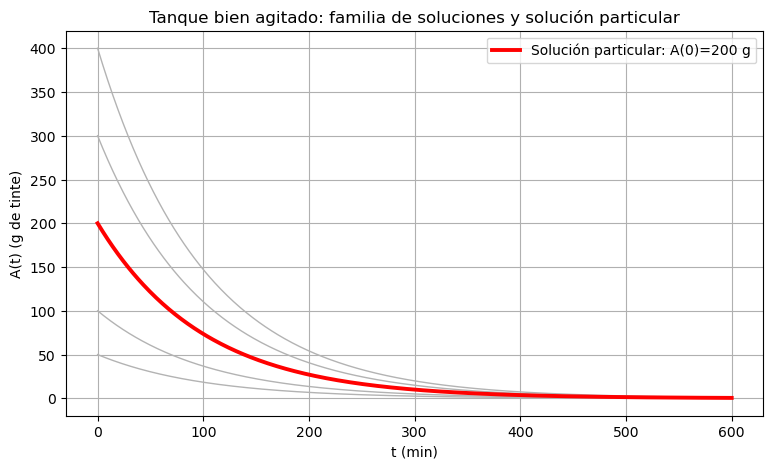

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del tanque
V = 200      # L
q = 2        # L/min
k = q / V    # 1/min  -> 0.01

# Dominio de tiempo (min)
t = np.linspace(0, 600, 500)  # 0 a 600 min (~10 h)

# Familia de soluciones: A(t) = C exp(-k t)
C_values = [50, 100,
            200, 300, 400]  # distintos valores iniciales A(0)=C

def A(t, C):
    return C * np.exp(-k * t)

plt.figure(figsize=(9,5))

# Graficar familia
for C in C_values:
    plt.plot(t, A(t, C), color="0.7", linewidth=1)

# Solución particular: A(0)=200
A_part = A(t, 200)
plt.plot(t, A_part, linewidth=2.8, label="Solución particular: A(0)=200 g", c="r")

plt.xlabel("t (min)")
plt.ylabel("A(t) (g de tinte)")
plt.title("Tanque bien agitado: familia de soluciones y solución particular")
plt.grid(True)
plt.legend()
plt.show()


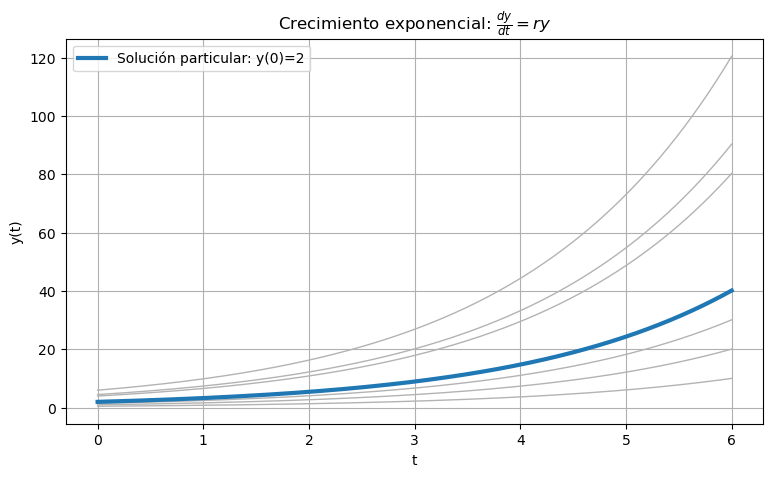

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetro de crecimiento
r = 0.5   # r > 0

# Tiempo
t = np.linspace(0, 6, 400)

# Familia de soluciones y(t) = C e^{rt}
C_values = [0.5, 1, 1.5, 2, 4,4.5, 6]

def y(t, C):
    return C * np.exp(r * t)

plt.figure(figsize=(9,5))

# Familia (gris)
for C in C_values:
    plt.plot(t, y(t, C), color="0.7", linewidth=1)

# Solución particular
y0 = 2
y_part = y(t, y0)
plt.plot(t, y_part, linewidth=3,
         label=f"Solución particular: y(0)={y0}")

plt.xlabel("t")
plt.ylabel("y(t)")
plt.title(r"Crecimiento exponencial: $\frac{dy}{dt}=ry$")
plt.grid(True)
plt.legend()
plt.show()




$$
\frac{d y}{d t}=y(r-a y)
$$


Tenemos:

$$
f(y)=y(r-a y) .
$$


Esto significa:

$$
y^{\prime}=f(y)
$$

la pendiente depende solo de $y$.

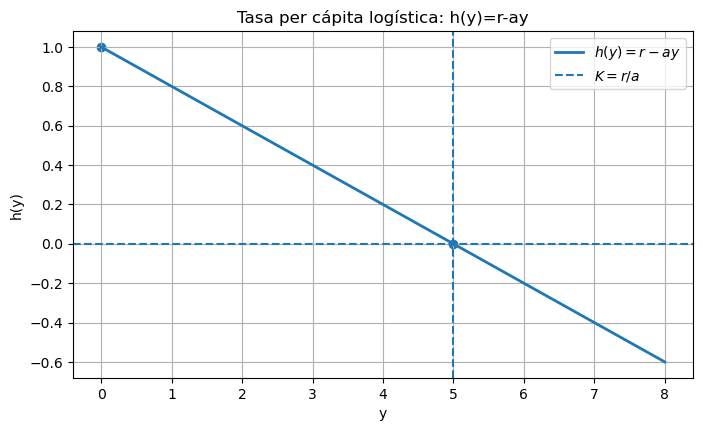

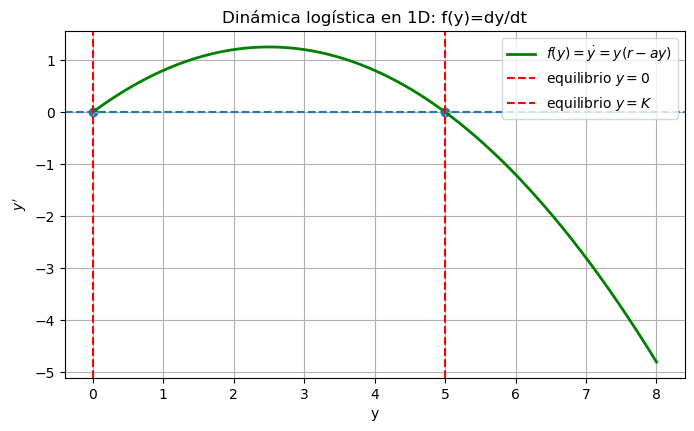

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del modelo (ajústalos)
r = 1.0
a = 0.2
K = r / a  # capacidad de carga

# --- Funciones del modelo ---
def h(y):
    return r - a*y

def f(y):
    return y * h(y)  # dy/dt

# --- 1) Graficar h(y) = r - a y ---
y_grid = np.linspace(0, 1.6*K, 600)

plt.figure(figsize=(8,4.5))
plt.plot(y_grid, h(y_grid), linewidth=2, label=r"$h(y)=r-ay$")
plt.axhline(0, linestyle="--")
plt.axvline(K, linestyle="--", label=r"$K=r/a$")
plt.scatter([0, K], [h(0), h(K)])
plt.xlabel("y")
plt.ylabel("h(y)")
plt.title("Tasa per cápita logística: h(y)=r-ay")
plt.grid(True)
plt.legend()
plt.show()

# --- 2) “Ecuación misma”: f(y)=dy/dt contra y  ---
plt.figure(figsize=(8,4.5))
plt.plot(y_grid, f(y_grid), linewidth=2, label=r"$f(y)=\dot y = y(r-ay)$", c='green')
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--", label=r"equilibrio $y=0$", c='r')
plt.axvline(K, linestyle="--", label=r"equilibrio $y=K$", c='r')
plt.scatter([0, K], [0, 0])
plt.xlabel("y")
plt.ylabel(r"$y'$")
plt.title("Dinámica logística en 1D: f(y)=dy/dt")
plt.grid(True)
plt.legend()
plt.show()


### “Si la población vale y, ¿sube o baja?”

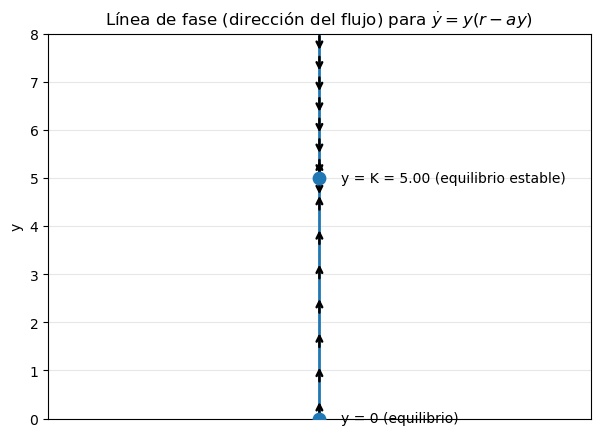

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del modelo logístico
r = 1.0
a = 0.2
K = r / a

def f(y):
    return y * (r - a*y)  # dy/dt

# Intervalos para la línea de fase (evitando los equilibrios exactos)
eps = 1e-3
intervals = [
    (0 + eps, K - eps),
    (K + eps, 1.6*K)
]

# Puntos donde pondremos flechas en cada intervalo
n_arrows = 8

fig, ax = plt.subplots(figsize=(7,5))

# Dibujar el eje y como línea vertical (fase 1D)
ax.plot([0, 0], [0, 1.6*K], linewidth=2)
ax.set_xlim(-1, 1)
ax.set_ylim(0, 1.6*K)

# Marcar equilibrios
ax.scatter([0, 0], [0, K], s=80, zorder=5)
ax.text(0.08, 0, "y = 0 (equilibrio)", va="center")
ax.text(0.08, K, f"y = K = {K:.2f} (equilibrio estable)", va="center")

# Flechas de dirección: donde f(y)>0 sube (↑), donde f(y)<0 baja (↓)
for (ymin, ymax) in intervals:
    ys = np.linspace(ymin, ymax, n_arrows)
    for y0 in ys:
        direction = np.sign(f(y0))
        # longitud pequeña de flecha
        dy = 0.08*K
        if direction > 0:
            # flecha hacia arriba
            ax.annotate(
                "", xy=(0, y0 + dy), xytext=(0, y0),
                arrowprops=dict(arrowstyle="->", lw=1.8)
            )
        elif direction < 0:
            # flecha hacia abajo
            ax.annotate(
                "", xy=(0, y0 - dy), xytext=(0, y0),
                arrowprops=dict(arrowstyle="->", lw=1.8)
            )

# Etiquetas y estilo
ax.set_xticks([])
ax.set_ylabel("y")
ax.set_title("Línea de fase (dirección del flujo) para $\\dot y = y(r - ay)$")
ax.grid(True, axis="y", alpha=0.3)

plt.show()

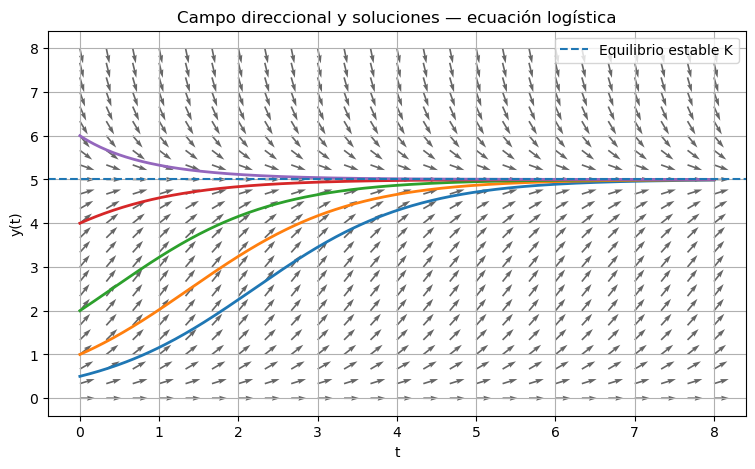

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros logísticos
r = 1.0
a = 0.2
K = r/a

def f(t, y):
    return y * (r - a*y)

# ----- Malla del campo direccional -----
t_vals = np.linspace(0, 8, 25)
y_vals = np.linspace(0, 1.6*K, 25)

T, Y = np.meshgrid(t_vals, y_vals)

# pendientes
S = f(T, Y)

# normalizar flechas (solo dirección)
dt = np.ones_like(S)
dy = S
norm = np.sqrt(dt**2 + dy**2)
dt /= norm
dy /= norm

plt.figure(figsize=(9,5))

# Campo direccional
plt.quiver(T, Y, dt, dy, alpha=0.6)

# ----- Soluciones logísticas -----
def logistic(t, y0):
    return K / (1 + ((K - y0)/y0)*np.exp(-r*t))

t = np.linspace(0,8,400)

y0_values = [0.5, 1, 2, 4, 6]

for y0 in y0_values:
    plt.plot(t, logistic(t, y0), linewidth=2)

# Equilibrio
plt.axhline(K, linestyle="--", label="Equilibrio estable K")

plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Campo direccional y soluciones — ecuación logística")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# --- 3) Soluciones explícitas y(t) para varias condiciones iniciales ---
# Solución (para y0 != 0): y(t)= K / (1 + ((K-y0)/y0)*e^{-rt})
def y_solution(t, y0):
    if y0 == 0:
        return np.zeros_like(t)
    return K / (1 + ((K - y0) / y0) * np.exp(-r*t))

# Tiempo
t = np.linspace(0, 10, 600)

# Familia de condiciones iniciales (incluye valores debajo y arriba de K)
y0_values = [0.2*K, 0.6*K, 0.9*K, 1.1*K, 1.5*K]

plt.figure(figsize=(9,5))

# Familia (gris)
for y0 in y0_values:
    plt.plot(t, y_solution(t, y0), color="0.7", linewidth=1)

# Resaltar una solución particular
y0_part = 0.6*K
plt.plot(t, y_solution(t, y0_part), linewidth=3,
         label=fr"Solución particular: $y(0)={y0_part:.2f}$")

# Equilibrio K (línea horizontal)
plt.axhline(K, linestyle="--", label=fr"$K={K:.2f}$ (equilibrio estable)")
plt.axhline(0, linestyle="--")

plt.xlabel("t")
plt.ylabel("y(t)")
plt.title(r"Verhulst (logística): $\dot y = y(r-ay)$ — familia de soluciones")
plt.grid(True)
plt.legend()
plt.show()